In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("diabetes.csv")

In [3]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>,
        <Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>],
       [<Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>, <Axes: >]], dtype=object)

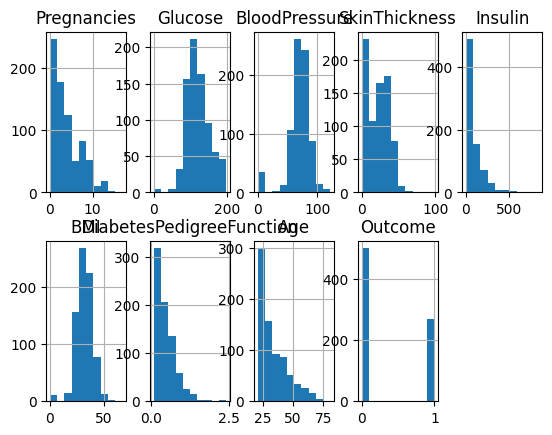

In [4]:
data.hist(layout=(2,5))

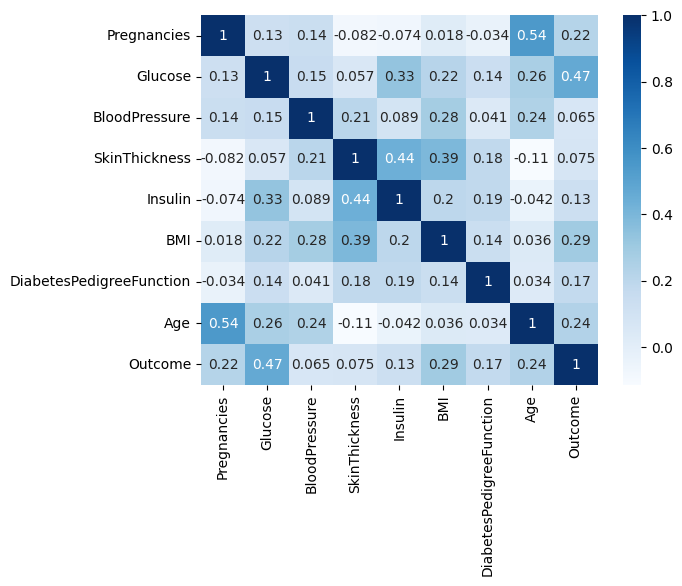

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(data.corr(),annot=True,cmap="Blues")
plt.show()

In [7]:
X = data.drop("Outcome",axis=1)
y = data["Outcome"]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [8]:
from tensorflow.keras.layers import Input,Dense,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
inp = Input(shape=(X_train.shape[1],))
x = Dense(40, activation='relu')(inp)
x = Dense(40, activation='relu')(x)
op = Dense(1, activation='sigmoid')(x)
model = Model(inputs=inp, outputs=op)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [13]:
print(X_train.iloc[5].values.shape)

(8,)


In [20]:
model.fit(X_train, y_train, batch_size=64, epochs=10, verbose=1)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6132 - loss: 10.3088
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3578 - loss: 2.8229 
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5748 - loss: 1.5632 
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5022 - loss: 1.0437 
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5955 - loss: 0.7995
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5849 - loss: 0.7731 
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6273 - loss: 0.6873 
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6352 - loss: 0.6750
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6452 - loss: 0.6938 
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6730 - loss: 0.6224 


In [23]:
model.evaluate(X_test, y_test)[1]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6197 - loss: 0.7575 


0.6038960814476013

In [24]:
query_instance = X_test.iloc[5].values.reshape((1,) + X_test.iloc[5].shape)
df_query = pd.DataFrame(data=query_instance, columns=X_test.columns)
df_query

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,103.0,72.0,32.0,190.0,37.7,0.324,55.0


In [25]:
import numpy as np

In [26]:
sigma_glucose = np.std(X['Glucose'])
sigma_bmi = np.std(X['BMI'])
sigma_age = np.std(X['Age'])
sigma_dpf = np.std(X['DiabetesPedigreeFunction'])
sigma_pregnancies = np.std(X['Pregnancies'])
sigma_insulin = np.std(X['Insulin'])
sigma_bp = np.std(X['BloodPressure'])

In [27]:
measure_tuple_list = [('Glucose', sigma_glucose),
                     ('BMI', sigma_bmi),
                     ('Age', sigma_age),
                     ('DiabetesPedigreeFunction', sigma_dpf),
                     ('Pregnancies', sigma_pregnancies),
                     ('Insulin', sigma_insulin),
                     ('BloodPressure', sigma_bp)]

In [28]:
measure,sigma=measure_tuple_list[0]

In [29]:
sensitivity_output = []
original = df_query[measure].copy()

In [31]:
for k in [-3,-2,-1,1,2,3]:
  df_query[measure] = original.copy()
  df_query[measure] = df_query[measure] + k*sigma
  sensitivity_output.append(model.predict(df_query)[0])
  print(model.predict(df_query))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[[5.6831013e-05]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
[[0.00935088]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
[[0.28490922]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[[0.18723977]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[[0.24781977]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
[[0.53156954]]


In [32]:
print(sensitivity_output)

[array([5.6831013e-05], dtype=float32), array([0.00935088], dtype=float32), array([0.28490922], dtype=float32), array([0.18723977], dtype=float32), array([0.24781977], dtype=float32), array([0.53156954], dtype=float32)]


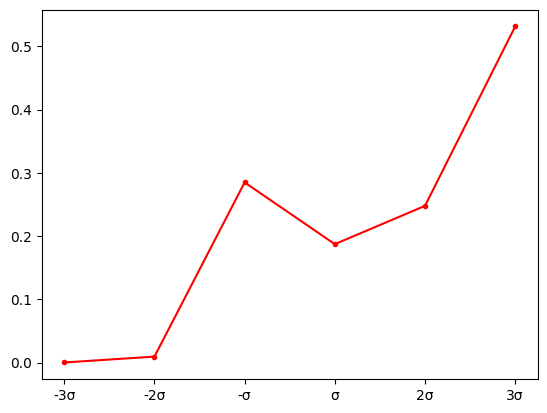

In [33]:
plt.plot(['-3σ', '-2σ', '-σ', 'σ', '2σ', '3σ'], sensitivity_output[:6], 'r.-', label = 'Sensitivity output')
